In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.dates as mdates
import numpy as np

In [2]:
df = pd.read_csv('Consumo_cerveja.csv')
df.head()

,Data,Temperatura Media (C),Temperatura Minima (C),Temperatura Maxima (C),Precipitacao (mm),Final de Semana,Consumo de cerveja (litros)
0,2015-01-01,"27,3","23,9","32,5",0,0.0,25.461
1,2015-01-02,"27,02","24,5","33,5",0,0.0,28.972
2,2015-01-03,"24,82","22,4","29,9",0,1.0,30.814
3,2015-01-04,"23,98","21,5","28,6","1,2",1.0,29.799
4,2015-01-05,"23,82",21,"28,3",0,0.0,28.900


In [3]:
df.tail()

,Data,Temperatura Media (C),Temperatura Minima (C),Temperatura Maxima (C),Precipitacao (mm),Final de Semana,Consumo de cerveja (litros)
936,NaN,NaN,NaN,NaN,NaN,NaN,NaN
937,NaN,NaN,NaN,NaN,NaN,NaN,NaN
938,NaN,NaN,NaN,NaN,NaN,NaN,NaN
939,NaN,NaN,NaN,NaN,NaN,NaN,NaN
940,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 941 entries, 0 to 940
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Data                         365 non-null    object 
 1   Temperatura Media (C)        365 non-null    object 
 2   Temperatura Minima (C)       365 non-null    object 
 3   Temperatura Maxima (C)       365 non-null    object 
 4   Precipitacao (mm)            365 non-null    object 
 5   Final de Semana              365 non-null    float64
 6   Consumo de cerveja (litros)  365 non-null    float64
dtypes: float64(2), object(5)
memory usage: 51.6+ KB


In [9]:
df.isnull().sum()

Data                           576
Temperatura Media (C)          576
Temperatura Minima (C)         576
Temperatura Maxima (C)         576
Precipitacao (mm)              576
Final de Semana                576
Consumo de cerveja (litros)    576
dtype: int64

In [11]:
df.dropna(how="all", inplace=True)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 365 entries, 0 to 364
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Data                         365 non-null    object 
 1   Temperatura Media (C)        365 non-null    object 
 2   Temperatura Minima (C)       365 non-null    object 
 3   Temperatura Maxima (C)       365 non-null    object 
 4   Precipitacao (mm)            365 non-null    object 
 5   Final de Semana              365 non-null    float64
 6   Consumo de cerveja (litros)  365 non-null    float64
dtypes: float64(2), object(5)
memory usage: 22.8+ KB


In [15]:
df.head(200)

,Data,Temperatura Media (C),Temperatura Minima (C),Temperatura Maxima (C),Precipitacao (mm),Final de Semana,Consumo de cerveja (litros)
0,2015-01-01,"27,3","23,9","32,5",0,0.0,25.461
1,2015-01-02,"27,02","24,5","33,5",0,0.0,28.972
2,2015-01-03,"24,82","22,4","29,9",0,1.0,30.814
3,2015-01-04,"23,98","21,5","28,6","1,2",1.0,29.799
4,2015-01-05,"23,82",21,"28,3",0,0.0,28.900
...,...,...,...,...,...,...,...
195,2015-07-15,"20,18","17,2","27,6",0,0.0,28.742
196,2015-07-16,"19,88","16,2","25,8",0,0.0,21.748
197,2015-07-17,"19,14","15,8","24,3",0,0.0,22.032
198,2015-07-18,"20,2","18,2","23,8",0,1.0,24.827


# ======================
# 1. Pré-processamento
# ======================

In [18]:
#Ajustando os dados
df['Data'] = pd.to_datetime(df['Data'], dayfirst=True, errors='coerce')
df = df.dropna(subset=['Data'])

cols_numericas = [
    'Temperatura Media (C)',
    'Temperatura Minima (C)',
    'Temperatura Maxima (C)',
    'Precipitacao (mm)',
]

for col in cols_numericas:
    df[col] = df[col].astype(str).str.replace(',','.')
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['Final de Semana'] = df['Final de Semana'].astype(int)
df= df.set_index('Data')

In [20]:
df.dtypes

Temperatura Media (C)          float64
Temperatura Minima (C)         float64
Temperatura Maxima (C)         float64
Precipitacao (mm)              float64
Final de Semana                  int32
Consumo de cerveja (litros)    float64
dtype: object

# ============================
# 2. Separar features e target
# ============================

In [23]:
X = df[[
    #'Temperatura Media (C)',
    #'Temperatura Minima (C)',
    'Temperatura Maxima (C)',
    #'Precipitacao (mm)',
    'Final de Semana',
]]
y = df['Consumo de cerveja (litros)']

# ==============================
# 3. Split treino/teste temporal
# ==============================

In [26]:
'''split = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]'''
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [28]:
X_train

,Temperatura Maxima (C),Final de Semana
Data,,
2015-01-01,32.5,0
2015-02-01,33.5,0
2015-03-01,29.9,1
2015-04-01,28.6,1
2015-05-01,28.3,0
...,...,...
2015-03-10,25.0,1
2015-04-10,21.3,1
2015-05-10,22.4,0


# ==============================
# 4. Escalonamento
# ==============================

In [31]:
# Treinar modelo
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==============================
# 5. Regressão Linear
# ==============================

In [34]:
# --- Treinamento ---
model = LinearRegression()
model.fit(X_train_scaled, y_train)
# --- Previsão ---
y_pred= pd.Series(model.predict(X_test_scaled), index=X_test.index)
# --- Garantir alinhamento ---
y_test.index = X_test.index

# ==============================
# 6. Avaliação
# ==============================

In [37]:
print('MAE: ', mean_absolute_error(y_test, y_pred))
print('RMSE: ', np.sqrt(mean_squared_error(y_test, y_pred)))
print('R²: ', r2_score(y_test, y_pred))

MAE:  2.255755393636587
RMSE:  2.6586492510038524
R²:  0.553355832954147


In [39]:
y_test.index



DatetimeIndex(['2015-08-10', '2015-09-10', '2015-10-10', '2015-11-10',
               '2015-12-10', '2015-01-11', '2015-02-11', '2015-03-11',
               '2015-04-11', '2015-05-11', '2015-06-11', '2015-07-11',
               '2015-08-11', '2015-09-11', '2015-10-11', '2015-11-11',
               '2015-12-11', '2015-01-12', '2015-02-12', '2015-03-12',
               '2015-04-12', '2015-05-12', '2015-06-12', '2015-07-12',
               '2015-08-12', '2015-09-12', '2015-10-12', '2015-11-12',
               '2015-12-12'],
              dtype='datetime64[ns]', name='Data', freq=None)

In [41]:


print("y_test type:", type(y_test))
print("y_test shape:", getattr(y_test, "shape", None))
print("y_pred type:", type(y_pred))
print("y_pred shape:", getattr(y_pred, "shape", None))

print("\nPrimeiros valores de y_test:")
print(y_test.head())

print("\nPrimeiros valores de y_pred:")
print(y_pred.head())


y_test type: <class 'pandas.core.series.Series'>
y_test shape: (29,)
y_pred type: <class 'pandas.core.series.Series'>
y_pred shape: (29,)

Primeiros valores de y_test:
Data
2015-08-10    33.182
2015-09-10    23.849
2015-10-10    33.330
2015-11-10    34.496
2015-12-10    26.249
Name: Consumo de cerveja (litros), dtype: float64

Primeiros valores de y_pred:
Data
2015-08-10    28.676804
2015-09-10    25.313823
2015-10-10    30.275002
2015-11-10    31.620194
2015-12-10    25.717381
dtype: float64


In [43]:
# ==============================
# 7. Visualização
# ==============================

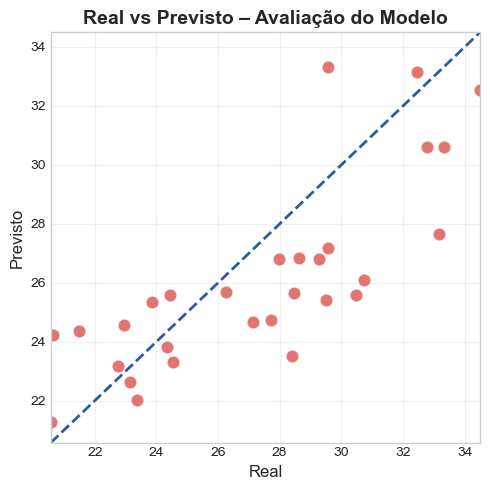

In [77]:
plt.figure(figsize=(5,5))
plt.style.use("seaborn-v0_8-whitegrid")

# Scatter real vs previsto
plt.scatter(y_test, y_pred_poly, color="#d9534f", alpha=0.8, s=90, edgecolor="white")

# Linha de perfeição
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val],
         color="#2a5d9f", linestyle="--", linewidth=2)

plt.xlabel("Real", fontsize=12)
plt.ylabel("Previsto", fontsize=12)
plt.title("Real vs Previsto – Avaliação do Modelo", fontsize=14, weight="bold")

# Deixar escala dos eixos igual
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [67]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import root_mean_squared_error

# --- Modelo Polinomial ---
model_poly = Pipeline([
    ("poly", PolynomialFeatures(degree=3)),   # teste degree=2 e degree=3
    ("linear", LinearRegression())
])

model_poly.fit(X_train, y_train)
y_pred_poly = model_poly.predict(X_test)

# --- Métricas ---
print("\nModelo: Regressão Polinomial (grau 3)")
print("MAE:", mean_absolute_error(y_test, y_pred_poly))
print("RMSE:", root_mean_squared_error(y_test, y_pred_poly))
print("R²:", r2_score(y_test, y_pred_poly))



Modelo: Regressão Polinomial (grau 3)
MAE: 2.3221297394855362
RMSE: 2.7453616903031364
R²: 0.5237459153826463


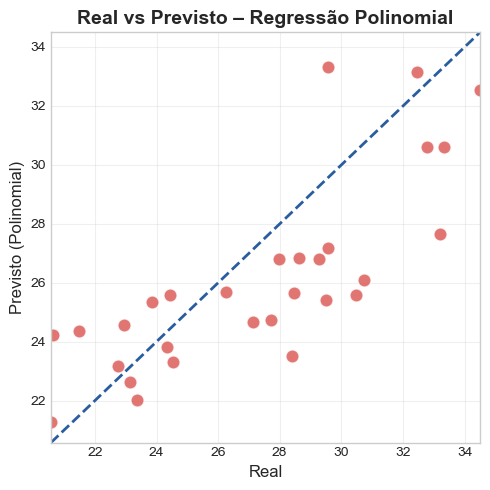

In [69]:
plt.figure(figsize=(5,5))
plt.style.use("seaborn-v0_8-whitegrid")

plt.scatter(y_test, y_pred_poly, color="#d9534f", alpha=0.8, s=90, edgecolor="white")

min_val = min(y_test.min(), y_pred_poly.min())
max_val = max(y_test.max(), y_pred_poly.max())

plt.plot([min_val, max_val], [min_val, max_val],
         color="#2a5d9f", linestyle="--", linewidth=2)

plt.xlabel("Real", fontsize=12)
plt.ylabel("Previsto (Polinomial)", fontsize=12)
plt.title("Real vs Previsto – Regressão Polinomial", fontsize=14, weight="bold")

plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [79]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

# --- Modelo Árvore de Decisão ---
tree = DecisionTreeRegressor(max_depth=5, random_state=42)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

print("\nModelo: Decision Tree")
print("MAE:", mean_absolute_error(y_test, y_pred_tree))
print("RMSE:", root_mean_squared_error(y_test, y_pred_tree))
print("R²:", r2_score(y_test, y_pred_tree))



Modelo: Decision Tree
MAE: 2.670845957693422
RMSE: 3.3086996520806187
R²: 0.3082418782149443


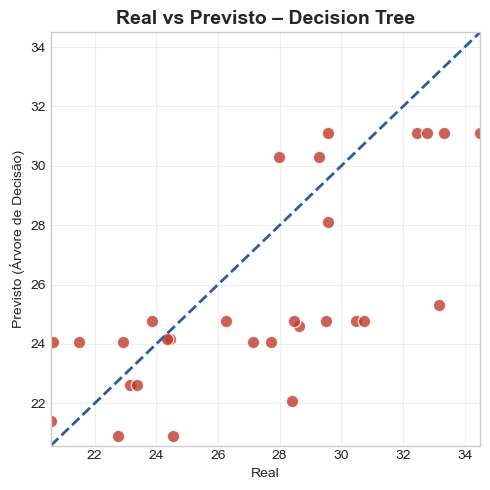

In [83]:
plt.figure(figsize=(5,5))
plt.style.use("seaborn-v0_8-whitegrid")

plt.scatter(y_test, y_pred_tree, color="#c0392b", alpha=0.8, s=80, edgecolor="white")

min_val = min(y_test.min(), y_pred_tree.min())
max_val = max(y_test.max(), y_pred_tree.max())

plt.plot([min_val, max_val], [min_val, max_val],
         color="#2a5d9f", linestyle="--", linewidth=2)

plt.xlabel("Real")
plt.ylabel("Previsto (Árvore de Decisão)")
plt.title("Real vs Previsto – Decision Tree", fontsize=14, weight="bold")

plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [85]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

resultados = {}

# --- Modelo 1: Regressão Linear ---
linear = LinearRegression()
linear.fit(X_train, y_train)
y_pred_linear = linear.predict(X_test)

resultados["Linear"] = {
    "MAE": mean_absolute_error(y_test, y_pred_linear),
    "RMSE": root_mean_squared_error(y_test, y_pred_linear),
    "R²": r2_score(y_test, y_pred_linear)
}

# --- Modelo 2: Polinomial (grau 3) ---
poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=3)),
    ("linear", LinearRegression())
])
poly_model.fit(X_train, y_train)
y_pred_poly = poly_model.predict(X_test)

resultados["Polinomial (Grau 3)"] = {
    "MAE": mean_absolute_error(y_test, y_pred_poly),
    "RMSE": root_mean_squared_error(y_test, y_pred_poly),
    "R²": r2_score(y_test, y_pred_poly)
}

# --- Modelo 3: Decision Tree ---
tree = DecisionTreeRegressor(max_depth=5, random_state=42)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

resultados["Decision Tree"] = {
    "MAE": mean_absolute_error(y_test, y_pred_tree),
    "RMSE": root_mean_squared_error(y_test, y_pred_tree),
    "R²": r2_score(y_test, y_pred_tree)
}

resultados


{'Linear': {'MAE': 2.2557553936365853,
  'RMSE': 2.6586492510038497,
  'R²': 0.553355832954148},
 'Polinomial (Grau 3)': {'MAE': 2.3221297394855362,
  'RMSE': 2.7453616903031364,
  'R²': 0.5237459153826463},
 'Decision Tree': {'MAE': 2.670845957693422,
  'RMSE': 3.3086996520806187,
  'R²': 0.3082418782149443}}

In [87]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Modelo: Random Forest")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", root_mean_squared_error(y_test, y_pred_rf))
print("R²:", r2_score(y_test, y_pred_rf))


Modelo: Random Forest
MAE: 2.6458861473428392
RMSE: 3.268054294199281
R²: 0.3251331411042009


In [ ]:
'''
“Apesar de testar Random Forest, o modelo apresentou overfitting e pior desempenho devido ao baixo volume de dados 
e alta variabilidade da série. 
Assim, a Regressão Linear continua sendo a melhor escolha para esse dataset.”
'''

In [ ]:
#pip install xgboost

In [94]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("Modelo: XGBoost")
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("RMSE:", root_mean_squared_error(y_test, y_pred_xgb))
print("R²:", r2_score(y_test, y_pred_xgb))


Modelo: XGBoost
MAE: 2.8828934394573342
RMSE: 3.467324454863528
R²: 0.2403237649636114


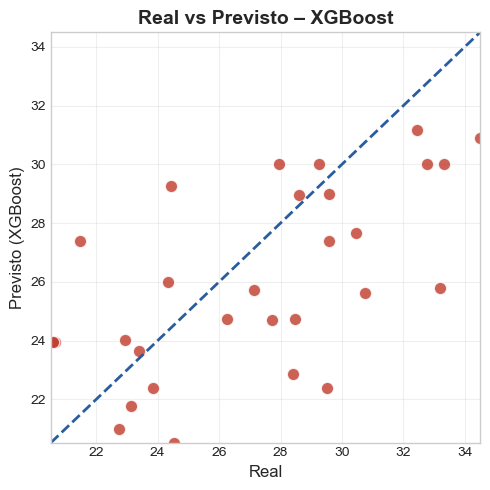

In [98]:
plt.figure(figsize=(5,5))
plt.style.use("seaborn-v0_8-whitegrid")

plt.scatter(y_test, y_pred_xgb, color="#c0392b", alpha=0.8, s=80, edgecolor="white")

min_val = min(y_test.min(), min(y_pred_xgb))
max_val = max(y_test.max(), max(y_pred_xgb))

plt.plot([min_val, max_val], [min_val, max_val],
         color="#2a5d9f", linestyle="--", linewidth=2)

plt.xlabel("Real", fontsize=12)
plt.ylabel("Previsto (XGBoost)", fontsize=12)
plt.title("Real vs Previsto – XGBoost", fontsize=14, weight="bold")

plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
| Modelo        | R²        | Comentário                         |
| ------------- | --------- | ---------------------------------- |
| **Linear**    | **0.553** | ⭐ melhor modelo, simples e estável |
| Polinomial    | 0.523     | médio, não ajuda                   |
| Decision Tree | 0.308     | fraco, overfit                     |
| Random Forest | 0.325     | fraco, overfit                     |
| XGBoost       | **0.240** | muito fraco, ruído+dados pequenos  |

'''
Modelos complexos pioram porque não existe padrão suficiente.
'''
| Modelo              | MAE      | RMSE     | R²        |
| ------------------- | -------- | -------- | --------- |
| **Linear**          | **2.25** | **2.65** | **0.553** |
| Polinomial (Grau 3) | 2.32     | 2.74     | 0.523     |
| Decision Tree       | 2.67     | 3.30     | 0.308     |
| Random Forest       | 2.64     | 3.26     | 0.325     |
| XGBoost             | 2.88     | 3.46     | 0.240     |


In [ ]:
## 🧠 2. Interpretação dos Resultados

Apesar de modelos mais sofisticados como Decision Tree, Random Forest e XGBoost 
serem amplamente utilizados em problemas complexos, 
o melhor desempenho neste dataset foi obtido com a Regressão Linear.

Isso acontece porque:
 Dataset é pequeno

Modelos de árvore tendem a sofrer overfitting e não generalizam bem.

 Variáveis explicativas têm baixo poder preditivo

Temperatura, umidade, final de semana e precipitação influenciam,
mas não conseguem prever totalmente o consumo.

 Alto nível de ruído nos dados

O consumo varia por vários fatores não observados.

 Relação entre variáveis é próxima de linear

A Regressão Linear captura bem a tendência geral,
enquanto modelos complexos tentam aprender padrões que não existem.

## ⭐ 3. Modelo Final Escolhido

A Regressão Linear foi o modelo final escolhido, obtendo o melhor R² (0.553), além do melhor MAE e RMSE.

Isso demonstra que, para esse dataset, modelos simples são mais eficazes do que algoritmos mais sofisticados.